# Single-Phase Percentage Strategy Backtest

Run one continuous percentage-based strategy for multiple Yahoo Finance tickers. Set the ticker list, date range, entry-relative exits, sizing, costs, and risk limits in **Block 1**, then run all cells.

The notebook downloads and caches daily OHLCV data, then compares the strategy only with buy-and-hold for the same ticker and period.

> This is a daily-bar research backtest, not an execution simulator or financial advice. If both the target and stop are touched during one daily candle, the default assumption is that the stop happened first.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from backtesting import (
    export_backtest_results,
    load_price_history_cached,
    plot_backtest_results,
    prepare_backtest_results,
    prepare_trade_details,
    run_price_intent_backtest,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format


## Block 1: Inputs

`start_date` and `end_date` define one continuous backtest period. Both are inclusive; `end_date = None` means the latest available session. There is no training/testing split and no remembered price level from an earlier phase.

Only the requested ticker histories are loaded; no benchmark or index data is downloaded or calculated.


In [2]:
# Instruments and single backtest period
ticker = ["CVX"]  # Each ticker gets an independent backtest and its own initial_capital.
start_date = "2024-01-01"  # First date included in the backtest.
end_date = None              # Last date included; None means the latest available session.

# Entry-relative strategy. Every new trade calculates fresh levels from its own fill.
market_entry_side = "long"       # "long" buys; "short" requires allow_short_selling=True.
allow_short_selling = False        # False keeps the strategy long-only.
profit_target_pct = 0.15           # Long target is 15% above entry; short target is 15% below.
initial_stop_loss_pct = 0.05       # Long stop is 5% below entry; short stop is 5% above.
trailing_stop_pct = 0.05           # Trail by 5% from the best completed high/low since entry.

# Capital, position, and order limits
initial_capital = 100.00  # Starting cash assigned separately to every ticker.
position_size_pct = 0.05  # Fraction of current cash committed per entry: 1.00 = 100%, 0.25 = 25%.
max_shares = None         # Maximum shares per position; None leaves the position limited only by cash.
whole_shares = False      # False permits fractional shares; True rounds the quantity down.
max_entries = 1000        # Maximum number of successfully opened positions during the period.
allow_reentry = True      # True permits another entry after a position has exited.
cooldown_days = 5         # Full trading sessions to wait after an exit before another entry.
min_holding_days = 30     # Top priority: block every normal exit, including all stops and targets, until N sessions.
max_holding_days = 1000   # Last priority: exit at close after N sessions only when no stop or target exits first.

# Execution assumptions
commission_per_order = 0.00  # Flat cash fee charged on every entry and exit order.
slippage_bps = 0.0           # Adverse fill adjustment: 10 basis points = 0.10% per order.
same_day_exit_priority = "target"  # If target and stop are both touched after entry, choose "stop" or "target".
entry_bar_exit_policy = "target"   # Entry-candle tie policy; min_holding_days > 0 prevents any entry-candle exit.
level_update_mode = "entry"      # Lock each trade's percentage-derived target and initial stop at entry.
allow_stop_widening = False         # False prevents an active stop from moving farther away from the position.
force_exit_at_end = False           # Separate override: True closes on the final close even if minimum hold is unmet.

# Cache and optional exports
cache_dir = "cache"            # Directory for downloaded ticker price history.
cache_max_age_hours = 24        # Cached files older than this are considered stale.
refresh_price_cache = True      # True requests fresh prices even when a usable cache file exists.
export_results = False          # True writes result tables to CSV files under output/.
save_chart = False              # True saves each chart under output/ in addition to displaying it.


## Block 2: Load the single-period market data

Each ticker is loaded once for the requested period and passed directly to the strategy. No benchmark, index membership, training split, trend model, or frozen channel is used.


In [3]:
normalized_tickers = list(dict.fromkeys(
    str(symbol).strip().upper()
    for symbol in ticker
    if symbol is not None and str(symbol).strip()
))
if not normalized_tickers:
    raise ValueError("ticker must contain at least one valid symbol")

start_ts = pd.Timestamp(start_date).normalize()
end_ts = (
    pd.Timestamp.today().normalize()
    if end_date is None
    else pd.Timestamp(end_date).normalize()
)
if end_ts < start_ts:
    raise ValueError("end_date must be on or after start_date")

market_data_by_ticker = {}
cache_rows = []

for current_ticker in normalized_tickers:
    price_history, cache_meta = load_price_history_cached(
        symbol=current_ticker,
        start=start_date,
        end=end_date,
        cache_root=cache_dir,
        max_age_hours=cache_max_age_hours,
        force_refresh=refresh_price_cache,
    )
    if price_history.empty:
        raise ValueError(f"{current_ticker} has no rows in the selected period")

    market_data_by_ticker[current_ticker] = {
        "price_history": price_history,
        "ticker_cache_meta": cache_meta,
    }
    cache_rows.append(dict(cache_meta))
    print(
        f"Loaded {len(price_history):,} {current_ticker} sessions from "
        f"{price_history['Date'].min():%Y-%m-%d} to "
        f"{price_history['Date'].max():%Y-%m-%d}."
    )

display(pd.DataFrame(cache_rows))


Loaded 657 CVX sessions from 2024-01-02 to 2026-08-14.


,symbol,rows,cache_used,stale_fallback,cache_age_hours,cache_file
0,CVX,657,False,False,0.00,cache\price_history\CVX_20240101_latest_1d.csv


## Block 3: Run the strategy

Each ticker runs independently with its own `initial_capital`. The algorithm enters at the first eligible session's open, calculates percentage exits from that fill, and repeats after later exits when re-entry is enabled.

Execution rules:

- Entry fills at the eligible session's opening price, adjusted for slippage.
- Long target = entry fill x (1 + `profit_target_pct`).
- Long initial stop = entry fill x (1 - `initial_stop_loss_pct`).
- The trailing stop follows the highest completed high by `trailing_stop_pct`.
- Short trades use the inverse calculations when explicitly enabled.
- First, `min_holding_days` must be reached; before then, fixed stops, trailing stops, targets, and time exits are ignored.
- After the minimum hold, fixed/trailing stops and the profit target are evaluated first.
- A gap through a target or stop fills at the opening price before slippage.
- If target and stop are both touched in one later candle, `same_day_exit_priority` decides the result.
- `max_holding_days` is checked last and exits only if no stop or target applies on that session.
- Open positions are marked to each close and optionally liquidated on the final session.


In [4]:
backtests_by_ticker = {}
actual_trade_level_frames = []
for current_ticker in normalized_tickers:
    market_data = market_data_by_ticker[current_ticker]
    backtest = run_price_intent_backtest(
        history=market_data["price_history"],
        benchmark=None,
        entry_limit=None,
        target=None,
        fixed_stop=None,
        capital=initial_capital,
        size_pct=position_size_pct,
        share_limit=max_shares,
        use_whole_shares=whole_shares,
        entries_limit=max_entries,
        reentry=allow_reentry,
        wait_days=cooldown_days,
        minimum_holding_days=min_holding_days,
        holding_limit=max_holding_days,
        trailing_pct=trailing_stop_pct,
        fee=commission_per_order,
        slip_bps=slippage_bps,
        priority=same_day_exit_priority,
        entry_bar_exit_policy=entry_bar_exit_policy,
        level_update_mode=level_update_mode,
        allow_stop_widening=allow_stop_widening,
        liquidate_at_end=force_exit_at_end,
        allow_short=allow_short_selling,
        entry_at_market=True,
        market_entry_side=market_entry_side,
        target_pct=profit_target_pct,
        fixed_stop_pct=initial_stop_loss_pct,
    )
    backtests_by_ticker[current_ticker] = backtest

    trade_levels = prepare_trade_details(backtest, ticker=current_ticker)
    if not trade_levels.empty:
        trade_levels = trade_levels.copy()
        trade_levels["trailing_stop_pct_points"] = (
            trade_levels["trailing_stop_pct"] * 100
        )
        actual_trade_level_frames.append(trade_levels[[
            "ticker", "trade_number", "side", "status",
            "entry_date", "entry_price", "planned_target_price",
            "planned_stop_price", "trailing_stop_pct_points",
            "planned_reward_risk_ratio", "exit_date", "exit_price",
            "exit_reason", "return_pct",
        ]])
    print(f"Completed backtest: {current_ticker}")

actual_trade_levels = (
    pd.concat(actual_trade_level_frames, ignore_index=True)
    if actual_trade_level_frames
    else pd.DataFrame({"message": ["No entries were executed."]})
)
strategy_settings = pd.Series({
    "entry_rule": f"Enter {market_entry_side} at each eligible session open",
    "exit_priority": "minimum hold -> stops/target -> maximum hold",
    "profit_target_pct_from_entry": profit_target_pct * 100,
    "initial_stop_pct_from_entry": initial_stop_loss_pct * 100,
    "trailing_stop_pct": trailing_stop_pct * 100,
    "initial_capital_per_ticker": initial_capital,
    "position_size_pct": position_size_pct * 100,
    "cooldown_sessions": cooldown_days,
    "min_holding_sessions": min_holding_days,
    "max_holding_sessions": max_holding_days,
    "commission_per_order": commission_per_order,
    "slippage_bps": slippage_bps,
}, name="value").to_frame()

display(strategy_settings)
display(actual_trade_levels)


Completed backtest: CVX


,value
entry_rule,Enter long at each eligible session open
exit_priority,minimum hold -> stops/target -> maximum hold
profit_target_pct_from_entry,15.00
initial_stop_pct_from_entry,5.00
trailing_stop_pct,5.00
initial_capital_per_ticker,100.00
position_size_pct,5.00
cooldown_sessions,5
min_holding_sessions,30
max_holding_sessions,1000


,ticker,trade_number,side,status,entry_date,entry_price,planned_target_price,planned_stop_price,trailing_stop_pct_points,planned_reward_risk_ratio,exit_date,exit_price,exit_reason,return_pct
0,CVX,1,LONG,CLOSED,2024-01-02,149.99,172.49,142.49,5.00,3.00,2024-03-04,148.80,TRAILING_STOP,-0.79
1,CVX,2,LONG,CLOSED,2024-03-12,151.83,174.60,144.24,5.00,3.00,2024-05-03,158.75,TRAILING_STOP,4.56
2,CVX,3,LONG,CLOSED,2024-05-13,166.48,191.45,158.16,5.00,3.00,2024-06-26,158.46,TRAILING_STOP,-4.82
3,CVX,4,LONG,CLOSED,2024-07-05,156.55,180.03,148.72,5.00,3.00,2024-08-16,146.05,TRAILING_STOP,-6.71
4,CVX,5,LONG,CLOSED,2024-08-26,148.97,171.32,141.52,5.00,3.00,2024-12-06,156.45,TRAILING_STOP,5.02
5,CVX,6,LONG,CLOSED,2024-12-16,153.89,176.97,146.20,5.00,3.00,2025-01-31,153.68,TRAILING_STOP,-0.14
6,CVX,7,LONG,CLOSED,2025-02-10,154.29,177.43,146.58,5.00,3.00,2025-04-03,160.12,TRAILING_STOP,3.78
7,CVX,8,LONG,CLOSED,2025-04-11,135.01,155.26,128.26,5.00,3.00,2025-05-27,136.52,TRAILING_STOP,1.12
8,CVX,9,LONG,CLOSED,2025-06-04,139.42,160.33,132.45,5.00,3.00,2025-07-18,148.10,TRAILING_STOP,6.22
9,CVX,10,LONG,CLOSED,2025-07-28,155.40,178.71,147.63,5.00,3.00,2025-10-01,153.77,TRAILING_STOP,-1.05


## Block 4: Results

The combined summary contains one row per ticker for the selected period. The order and round-trip tables include a ticker column so every fill remains attributable to its backtest.


In [5]:
results_by_ticker = {}
summary_frames = []
transaction_frames = []
round_trip_frames = []
equity_frames = []
exported_files_by_ticker = {}
for current_ticker, backtest in backtests_by_ticker.items():
    ticker_results = prepare_backtest_results(backtest)
    results_by_ticker[current_ticker] = ticker_results
    for source_name, destination in [
        ("summary", summary_frames),
        ("transactions", transaction_frames),
        ("round_trips", round_trip_frames),
        ("equity_curve", equity_frames),
    ]:
        labeled_frame = ticker_results[source_name].copy()
        labeled_frame.insert(0, "ticker", current_ticker)
        destination.append(labeled_frame)

    if export_results:
        exported_files_by_ticker[current_ticker] = export_backtest_results(
            backtest, current_ticker, start_date
        )

summary = pd.concat(summary_frames, ignore_index=True)
transactions = pd.concat(transaction_frames, ignore_index=True)
round_trips = pd.concat(round_trip_frames, ignore_index=True)
equity_curve = pd.concat(equity_frames, ignore_index=True)

display(summary)
display(
    transactions
    if not transactions.empty
    else pd.DataFrame({"message": ["No orders filled for any ticker."]})
)
display(
    round_trips
    if not round_trips.empty
    else pd.DataFrame({"message": ["No completed round trips for any ticker."]})
)

if export_results:
    export_directory = next(
        iter(next(iter(exported_files_by_ticker.values())).values())
    ).parent.resolve()
    print(
        f"Exported {len(exported_files_by_ticker)} ticker backtests to "
        f"{export_directory}"
    )


,ticker,start_date,end_date,initial_capital,ending_equity,strategy_return_pct,annualized_return_pct,buy_hold_return_pct,excess_vs_buy_hold_pct_points,max_drawdown_pct,...,winning_trades,win_rate_pct,total_realized_pnl,exposure_pct,average_trade_pnl,average_holding_sessions,profit_factor,total_commissions,turnover_multiple,entry_bar_ambiguities
0,CVX,2024-01-02,2026-08-14,100.00,101.50,1.50,0.57,48.81,-47.31,-1.19,...,7,46.67,1.01,86.30,0.07,36.33,1.66,0.00,1.56,0


,ticker,Date,action,side,reason,raw_price,fill_price,shares,gross_value,commission,cash_after,realized_pnl,entry_number
0,CVX,2024-01-02,BUY,LONG,MARKET_ENTRY,149.99,149.99,0.03,5.00,0.00,95.00,NaN,1
1,CVX,2024-03-04,SELL,LONG,TRAILING_STOP,148.80,148.80,0.03,4.96,0.00,99.96,-0.04,1
2,CVX,2024-03-12,BUY,LONG,MARKET_ENTRY,151.83,151.83,0.03,5.00,0.00,94.96,NaN,2
3,CVX,2024-05-03,SELL,LONG,TRAILING_STOP,158.75,158.75,0.03,5.23,0.00,100.19,0.23,2
4,CVX,2024-05-13,BUY,LONG,MARKET_ENTRY,166.48,166.48,0.03,5.01,0.00,95.18,NaN,3
5,CVX,2024-06-26,SELL,LONG,TRAILING_STOP,158.46,158.46,0.03,4.77,0.00,99.95,-0.24,3
6,CVX,2024-07-05,BUY,LONG,MARKET_ENTRY,156.55,156.55,0.03,5.00,0.00,94.95,NaN,4
7,CVX,2024-08-16,SELL,LONG,TRAILING_STOP,146.05,146.05,0.03,4.66,0.00,99.61,-0.34,4
8,CVX,2024-08-26,BUY,LONG,MARKET_ENTRY,148.97,148.97,0.03,4.98,0.00,94.63,NaN,5
9,CVX,2024-12-06,SELL,LONG,TRAILING_STOP,156.45,156.45,0.03,5.23,0.00,99.86,0.25,5


,ticker,entry_number,side,entry_date,exit_date,entry_price,exit_price,shares,exit_reason,holding_sessions,pnl,return_pct
0,CVX,1,LONG,2024-01-02,2024-03-04,149.99,148.80,0.03,TRAILING_STOP,42,-0.04,-0.79
1,CVX,2,LONG,2024-03-12,2024-05-03,151.83,158.75,0.03,TRAILING_STOP,37,0.23,4.56
2,CVX,3,LONG,2024-05-13,2024-06-26,166.48,158.46,0.03,TRAILING_STOP,30,-0.24,-4.82
3,CVX,4,LONG,2024-07-05,2024-08-16,156.55,146.05,0.03,TRAILING_STOP,30,-0.34,-6.71
4,CVX,5,LONG,2024-08-26,2024-12-06,148.97,156.45,0.03,TRAILING_STOP,72,0.25,5.02
5,CVX,6,LONG,2024-12-16,2025-01-31,153.89,153.68,0.03,TRAILING_STOP,30,-0.01,-0.14
6,CVX,7,LONG,2025-02-10,2025-04-03,154.29,160.12,0.03,TRAILING_STOP,37,0.19,3.78
7,CVX,8,LONG,2025-04-11,2025-05-27,135.01,136.52,0.04,TRAILING_STOP,30,0.06,1.12
8,CVX,9,LONG,2025-06-04,2025-07-18,139.42,148.10,0.04,TRAILING_STOP,30,0.31,6.22
9,CVX,10,LONG,2025-07-28,2025-10-01,155.40,153.77,0.03,TRAILING_STOP,46,-0.05,-1.05


## Block 5: Price and performance charts


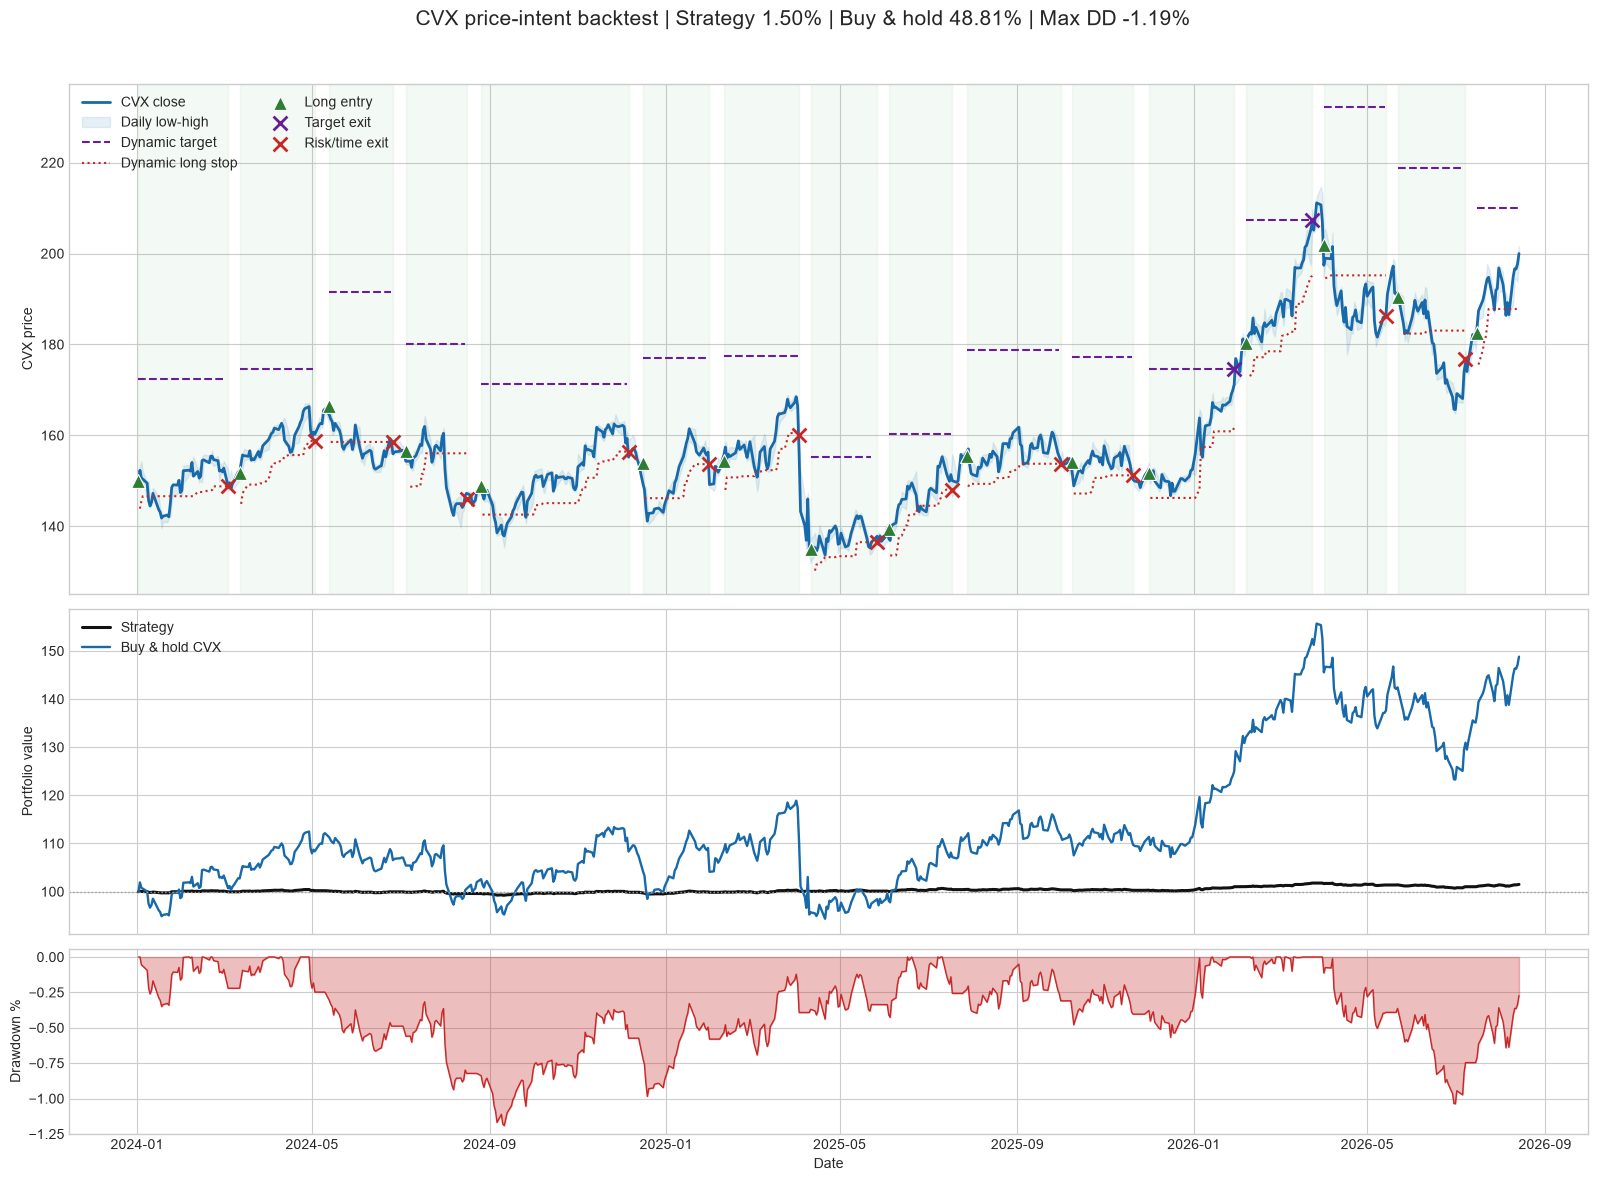

In [6]:
figures_by_ticker = {}
chart_files_by_ticker = {}
for current_ticker, backtest in backtests_by_ticker.items():
    equity_levels = backtest["equity_curve"]
    fig, chart_file = plot_backtest_results(
        backtest=backtest,
        ticker=current_ticker,
        buy_price=None,
        sell_price=equity_levels["target"],
        stop_loss=equity_levels["active_stop"],
        initial_capital=initial_capital,
        chart_output_dir="output" if save_chart else None,
    )
    figures_by_ticker[current_ticker] = fig
    chart_files_by_ticker[current_ticker] = chart_file
    if chart_file is not None:
        print(f"Saved {current_ticker} chart to {chart_file.resolve()}")
    plt.show()


## Block 6: Simulated trade execution details

One row per simulated trade across every ticker, including the filled entry and exit, quantity, fees, entry-time target and risk levels, holding period, and realized result. These are historical research fills—not live orders or a recommendation to trade.


In [7]:
trade_detail_frames = [
    prepare_trade_details(backtest, ticker=current_ticker)
    for current_ticker, backtest in backtests_by_ticker.items()
]
trade_details = pd.concat(trade_detail_frames, ignore_index=True)

if trade_details.empty:
    display(pd.DataFrame({"message": ["No simulated trade entries were executed."]}))
else:
    display(trade_details.sort_values(["entry_date", "ticker"]))

if export_results:
    for current_ticker, exported_files in exported_files_by_ticker.items():
        print(
            f"{current_ticker} trade-detail CSV: "
            f"{exported_files['trade_details'].resolve()}"
        )

,trade_number,ticker,side,status,buy_date,buy_price,sell_date,sell_price,entry_action,entry_date,...,exit_action,exit_date,exit_price,exit_notional,exit_commission,cash_after_exit,exit_reason,holding_sessions,realized_pnl,return_pct
0,1,CVX,LONG,CLOSED,2024-01-02,149.99,2024-03-04,148.80,BUY,2024-01-02,...,SELL,2024-03-04,148.80,4.96,0.00,99.96,TRAILING_STOP,42.00,-0.04,-0.79
1,2,CVX,LONG,CLOSED,2024-03-12,151.83,2024-05-03,158.75,BUY,2024-03-12,...,SELL,2024-05-03,158.75,5.23,0.00,100.19,TRAILING_STOP,37.00,0.23,4.56
2,3,CVX,LONG,CLOSED,2024-05-13,166.48,2024-06-26,158.46,BUY,2024-05-13,...,SELL,2024-06-26,158.46,4.77,0.00,99.95,TRAILING_STOP,30.00,-0.24,-4.82
3,4,CVX,LONG,CLOSED,2024-07-05,156.55,2024-08-16,146.05,BUY,2024-07-05,...,SELL,2024-08-16,146.05,4.66,0.00,99.61,TRAILING_STOP,30.00,-0.34,-6.71
4,5,CVX,LONG,CLOSED,2024-08-26,148.97,2024-12-06,156.45,BUY,2024-08-26,...,SELL,2024-12-06,156.45,5.23,0.00,99.86,TRAILING_STOP,72.00,0.25,5.02
5,6,CVX,LONG,CLOSED,2024-12-16,153.89,2025-01-31,153.68,BUY,2024-12-16,...,SELL,2025-01-31,153.68,4.99,0.00,99.85,TRAILING_STOP,30.00,-0.01,-0.14
6,7,CVX,LONG,CLOSED,2025-02-10,154.29,2025-04-03,160.12,BUY,2025-02-10,...,SELL,2025-04-03,160.12,5.18,0.00,100.04,TRAILING_STOP,37.00,0.19,3.78
7,8,CVX,LONG,CLOSED,2025-04-11,135.01,2025-05-27,136.52,BUY,2025-04-11,...,SELL,2025-05-27,136.52,5.06,0.00,100.10,TRAILING_STOP,30.00,0.06,1.12
8,9,CVX,LONG,CLOSED,2025-06-04,139.42,2025-07-18,148.10,BUY,2025-06-04,...,SELL,2025-07-18,148.10,5.32,0.00,100.41,TRAILING_STOP,30.00,0.31,6.22
9,10,CVX,LONG,CLOSED,2025-07-28,155.40,2025-10-01,153.77,BUY,2025-07-28,...,SELL,2025-10-01,153.77,4.97,0.00,100.36,TRAILING_STOP,46.00,-0.05,-1.05
